In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import binary_closing, binary_dilation
from skimage.morphology import ball

from utils import (
    load_config_json,
    scale_config_to_resolution,
    plot_mip_projection,
    plot_slices,
    visualize_circles_on_slices,
    visualize_aorta_with_ostia,
    find_ostia,
    region_growing_segmentation,
    dice_score,
    check_ostium_intersection,
    visualize_3d_k3d,
    load_raw_img_and_label,
    get_or_detect_aorta_circles,
    get_or_segment_aorta,
    get_or_compute_vesselness,
    run_core_preprocessing_pipeline,
    downscale_image_ndi,
)

# Segmentar Artéria via Crescimento de Região

## Carregar dados

In [2]:
CONFIG_FILE = os.path.abspath(os.path.join('..', 'config', 'pipeline_config.json'))
RESOLUTION = 'high'  # 'high' ou 'mid'

if not os.path.exists(CONFIG_FILE):
    raise FileNotFoundError(f"Arquivo de configuracao nao encontrado: {CONFIG_FILE}")

CONFIG = load_config_json(CONFIG_FILE, {})
if RESOLUTION == 'high':
    CONFIG['DOWNSCALE_FACTORS'] = [1, 1, 1]
CONFIG = scale_config_to_resolution(CONFIG)

print(f"Configuracao carregada de: {CONFIG_FILE}")

LOAD_CACHE = bool(CONFIG['LOAD_CACHE'])
SAVE_CACHE = bool(CONFIG['SAVE_CACHE'])

IMG_ID = 774

#base_path = '/media/matheus/HD/DatasetsCCTA/ImageCAS/1-1000'
base_path = '/data04/home/mpmaia/ImageCAS/database/1-1000'
base_save_path = '/media/matheus/HD/DatasetsCCTA/Processed_ImageCAS'

nii_img, nii_label = load_raw_img_and_label(
        f"{base_path}/{IMG_ID}.img.nii.gz", f"{base_path}/{IMG_ID}.label.nii.gz"
    )
spacing = nii_img.header.get_zooms()
img = np.array(nii_img.get_fdata(), dtype=np.float32)
label = np.array(nii_label.get_fdata()).astype(np.uint8)

downscale_factors = CONFIG["DOWNSCALE_FACTORS"]

down_image, thresh_image, lcc_image, thresh_vals = run_core_preprocessing_pipeline(
    img,
    downscale_factors=downscale_factors,
    lcc_per_slice=True,
    max_threshold_percentile=CONFIG["MAX_THRESHOLD_PERCENTILE"],
    use_opencv=False,
)
label = downscale_image_ndi(label, downscale_factors, order=0)

dx, dy, dz = (
    spacing[0] * downscale_factors[0],
    spacing[1] * downscale_factors[1],
    spacing[2] * downscale_factors[2],
    )

img_target = lcc_image

print(f"Imagem reduzida: {down_image.shape}, Espacamento: ({dx:.2f}, {dy:.2f}, {dz:.2f})")
print(f"Valores de thresholding: Min valor: {thresh_vals[0]}, Max valor: {thresh_vals[1]}")

vmin, vmax = lcc_image.min(), lcc_image.max()

affine_downscaled = nii_img.affine.copy()
affine_downscaled[0, 0] /= downscale_factors[0]
affine_downscaled[1, 1] /= downscale_factors[1]
affine_downscaled[2, 2] /= downscale_factors[2]

print('=' * 70)
print('INFORMACOES DA IMAGEM')
print('=' * 70)
print(f'ID da imagem:         {IMG_ID}')
print(f'Espacamento original: {spacing}')
print(f'Espacamento ajustado: ({dx:.4f}, {dy:.4f}, {dz:.4f})')
print(f'Shape da imagem:      {lcc_image.shape}')
print(f'Range de intensidade: [{lcc_image.min()}, {lcc_image.max()}]')
print('=' * 70 + '\n')

Configuracao carregada de: /data04/home/projetos/dac_seg_dlag/mssilva.ppgmc/matheus_codes/coronary-centerline-detection/config/pipeline_config.json
Imagem reduzida: (512, 512, 235), Espacamento: (0.32, 0.32, 0.50)
Valores de thresholding: Min valor: -300, Max valor: 862
INFORMACOES DA IMAGEM
ID da imagem:         774
Espacamento original: (np.float32(0.31835938), np.float32(0.31835938), np.float32(0.5))
Espacamento ajustado: (0.3184, 0.3184, 0.5000)
Shape da imagem:      (512, 512, 235)
Range de intensidade: [-300.0, 862.0]



PREPROCESSING COMPARISON - CENTRAL SLICE


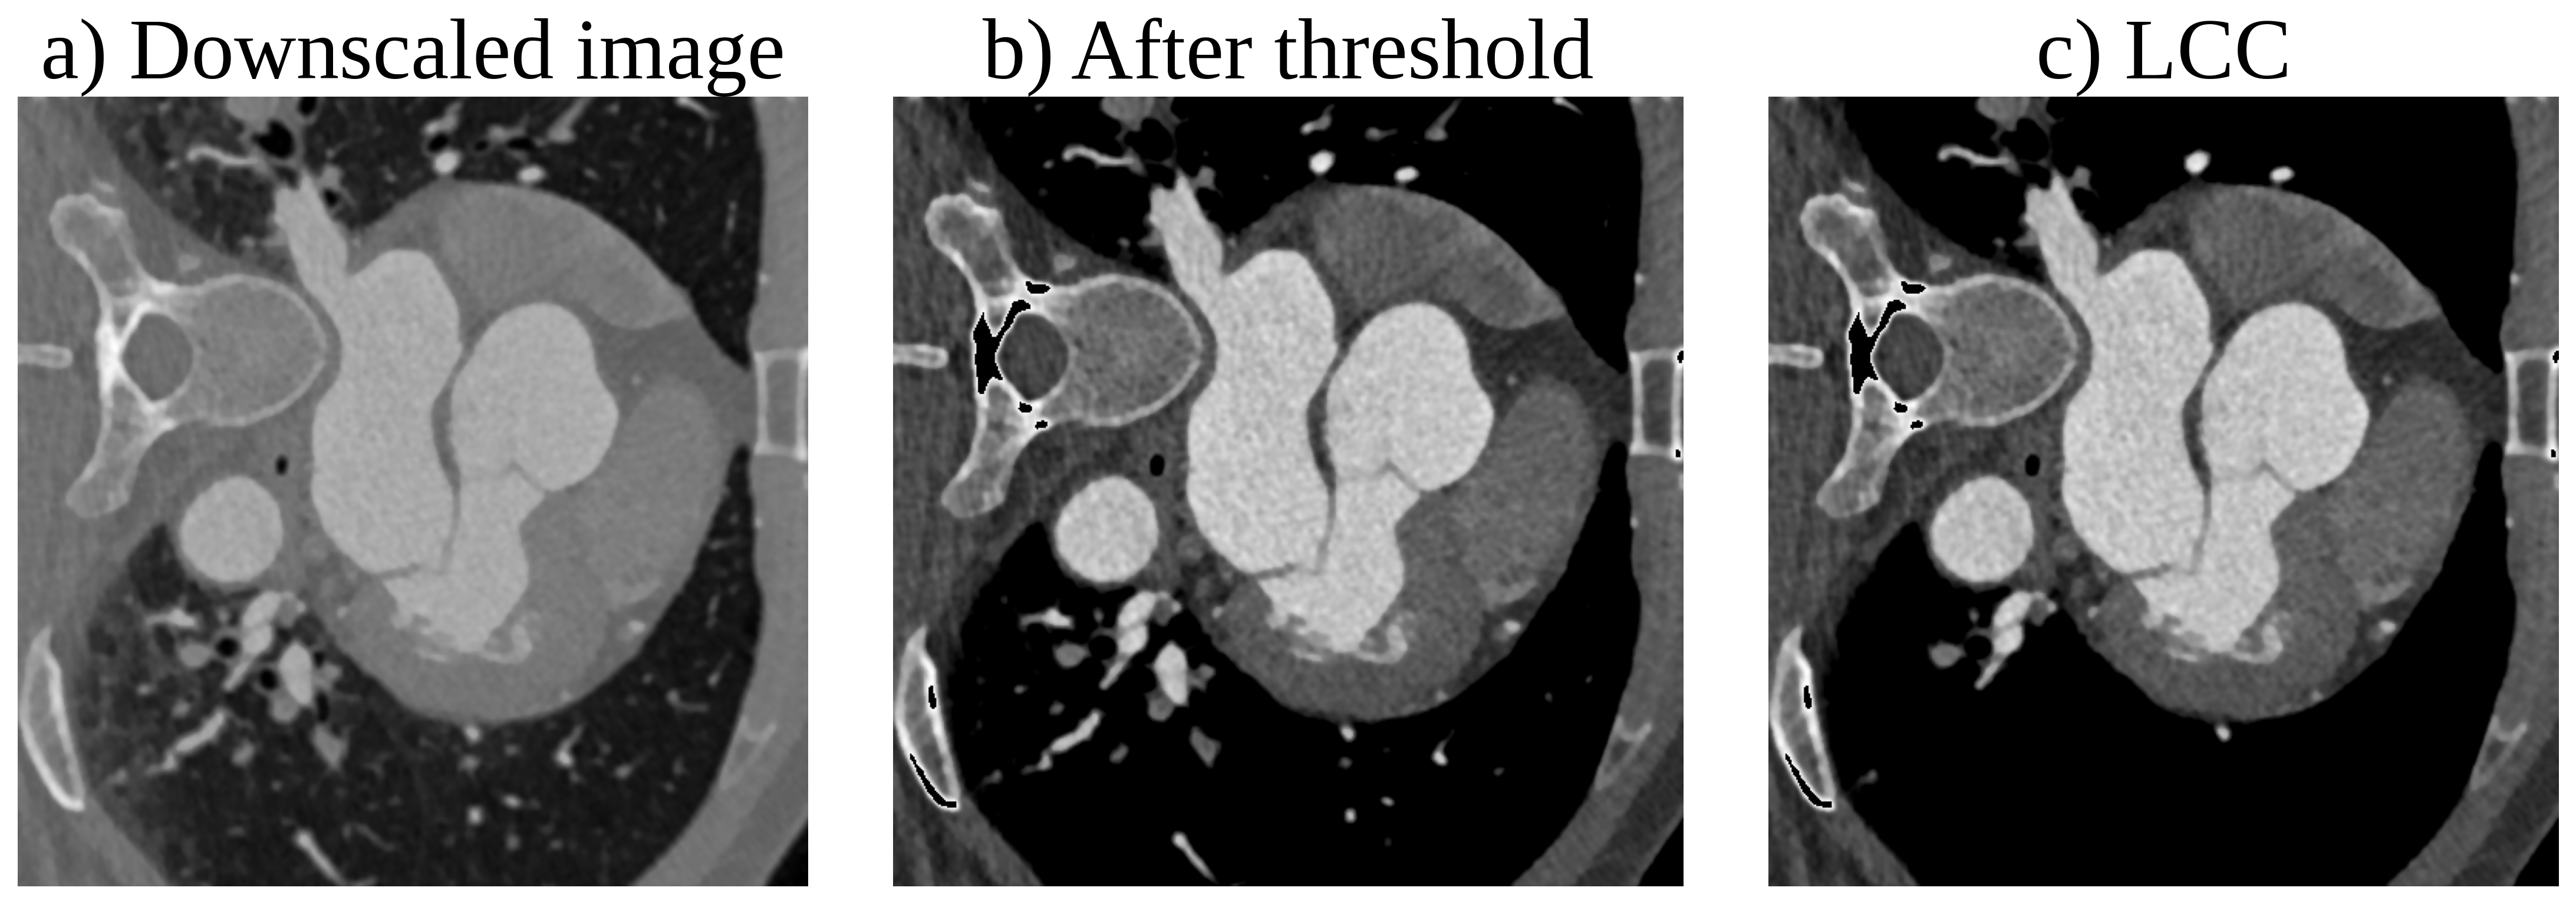

Central slice index: 176



In [3]:
print('=' * 70)
print('PREPROCESSING COMPARISON - CENTRAL SLICE')
print('=' * 70)

slice_idx = int(lcc_image.shape[2] * 0.75)

down_slice = down_image[:, :, slice_idx]
thresh_slice = thresh_image[:, :, slice_idx]
lcc_slice = lcc_image[:, :, slice_idx]

plt.rcParams['font.family'] = 'Liberation Serif'

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

axes[0].imshow(down_slice, cmap='gray')
axes[0].set_title('a) Downscaled image', fontsize=35, fontname='Liberation Serif')
axes[0].axis('off')

axes[1].imshow(thresh_slice, cmap='gray')
axes[1].set_title('b) After threshold', fontsize=35, fontname='Liberation Serif')
axes[1].axis('off')

axes[2].imshow(lcc_slice, cmap='gray')
axes[2].set_title('c) LCC', fontsize=35, fontname='Liberation Serif')
axes[2].axis('off')

fig.tight_layout()
plt.show()

print(f'Central slice index: {slice_idx}')
print('=' * 70 + '\n')

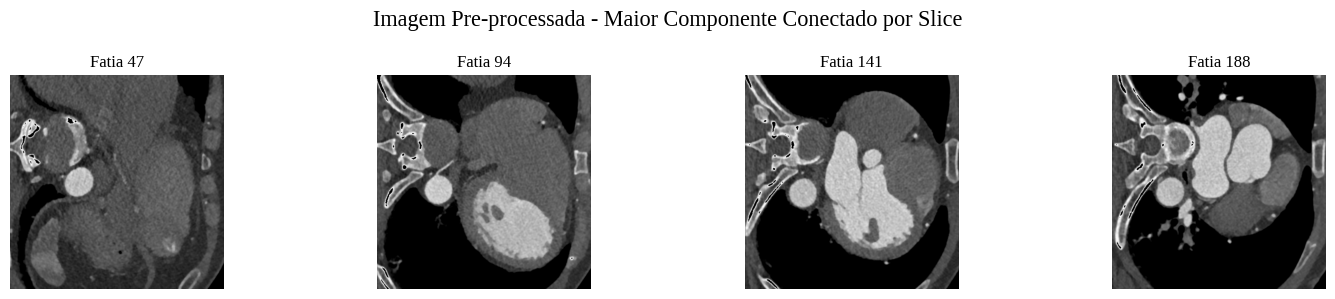

In [4]:
vmin, vmax = lcc_image.min(), lcc_image.max()
slices_to_plot = [
    int(lcc_image.shape[2] * 0.2),
    int(lcc_image.shape[2] * 0.4),
    int(lcc_image.shape[2] * 0.6),
    int(lcc_image.shape[2] * 0.8),
]
plot_slices(
    lcc_image,
    slices_to_plot,
    title='Imagem Pre-processada - Maior Componente Conectado por Slice',
)

## Segmentação Aorta Ascendente

### Localizar circulos Aorta

DETECCAO DE CIRCULOS DA AORTA
Parada na fatia 147: Δr=0.00 ou dist=66.85
Circulos detectados: 87
ROI local: True | padding: 30



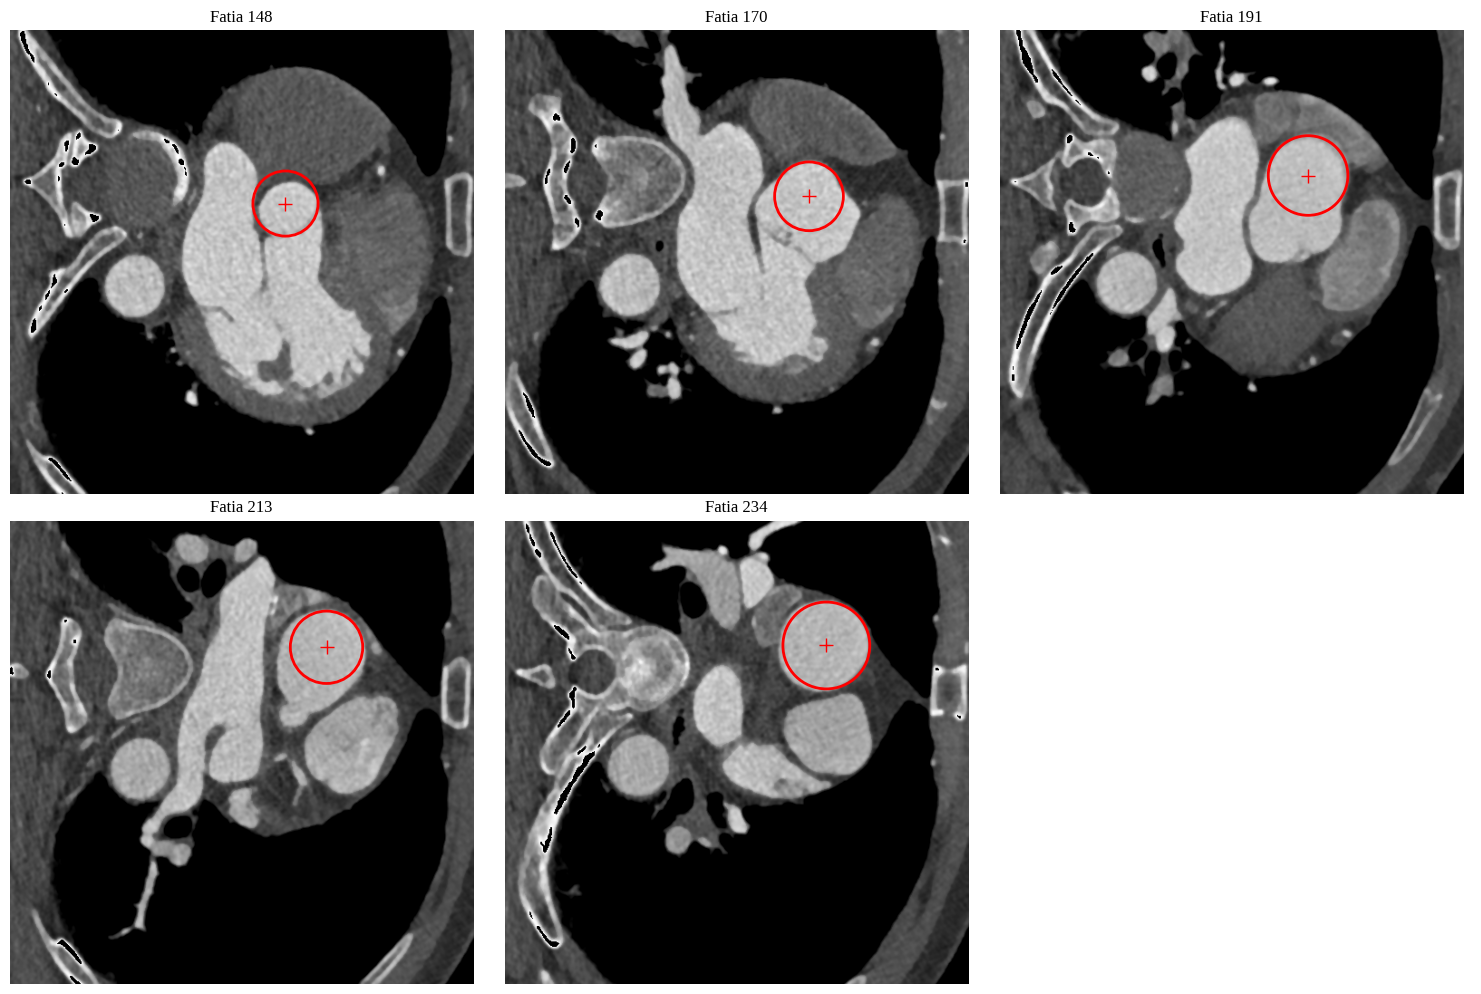

In [5]:
print('=' * 70)
print('DETECCAO DE CIRCULOS DA AORTA')
print('=' * 70)

detected_circles = get_or_detect_aorta_circles(
    IMG_ID,
    lcc_image,
    downscale_factors,
    (dx, dy, dz),
    CONFIG['CIRCLE_DETECTION'],
    base_save_path,
    load_cache=LOAD_CACHE,
    save_cache=SAVE_CACHE,
)

print(f"Circulos detectados: {len(detected_circles)}")
print(
    f"ROI local: {CONFIG['CIRCLE_DETECTION']['use_local_roi']} | "
    f"padding: {CONFIG['CIRCLE_DETECTION']['local_roi_padding']}"
 )
print('=' * 70 + '\n')

num_samples = 5
if len(detected_circles) > num_samples:
    indices = np.linspace(0, len(detected_circles) - 1, num_samples, dtype=int)
    sampled_circles = [detected_circles[i] for i in indices]
else:
    sampled_circles = detected_circles

visualize_circles_on_slices(
    img_target, sampled_circles, num_samples=num_samples, vmin=vmin, vmax=vmax
)

### Segmentar Aorta

In [6]:
saved_dir_aorta = f"{base_save_path}/segmented_aorta"
mask_path = os.path.join(saved_dir_aorta, f"{IMG_ID}_mask_aorta.npy")

aorta_mask = get_or_segment_aorta(
    IMG_ID,
    lcc_image,
    detected_circles,
    CONFIG['LEVEL_SET'],
    base_save_path,
    load_cache=LOAD_CACHE,
    save_cache=SAVE_CACHE,
).astype(np.uint8)

if LOAD_CACHE and os.path.exists(mask_path):
    print('=' * 70)
    print('SEGMENTACAO DA AORTA - CARREGADA DO CACHE')
    print('=' * 70)
    print(f"Mascara carregada: {aorta_mask.shape}")
    print(f"Valores unicos:    {np.unique(aorta_mask)}")
    print(f"Voxels de aorta:   {np.sum(aorta_mask):,}")
    print('=' * 70 + '\n')
else:
    print('=' * 70)
    print('SEGMENTACAO DA AORTA - CALCULADA')
    print('=' * 70)
    print(f"Aorta segmentada: {aorta_mask.shape}")
    print(f"Voxels: {np.sum(aorta_mask):,}")

    if SAVE_CACHE:
        print(f"\nMascara salva em: {mask_path}")
    else:
        print("\nMascara nao foi salva (SAVE_CACHE=False)")

    print('=' * 70 + '\n')

plot = visualize_3d_k3d(
    aorta_mask,
    spacing=(dx, dy, dz),
    color=0xff0000,
    opacity=0.7,
)

SEGMENTACAO DA AORTA - CALCULADA
Aorta segmentada: (512, 512, 235)
Voxels: 782,075

Mascara nao foi salva (SAVE_CACHE=False)

Gerando mesh 3D...


Output()

## Mapa de Vesselness

MAPA DE VESSELNESS (OSTIOS) - CALCULADO
Shape:   (512, 512, 235)
Range:   [0.0000, 0.6874]
Media:   0.0019
Desvpad: 0.0140



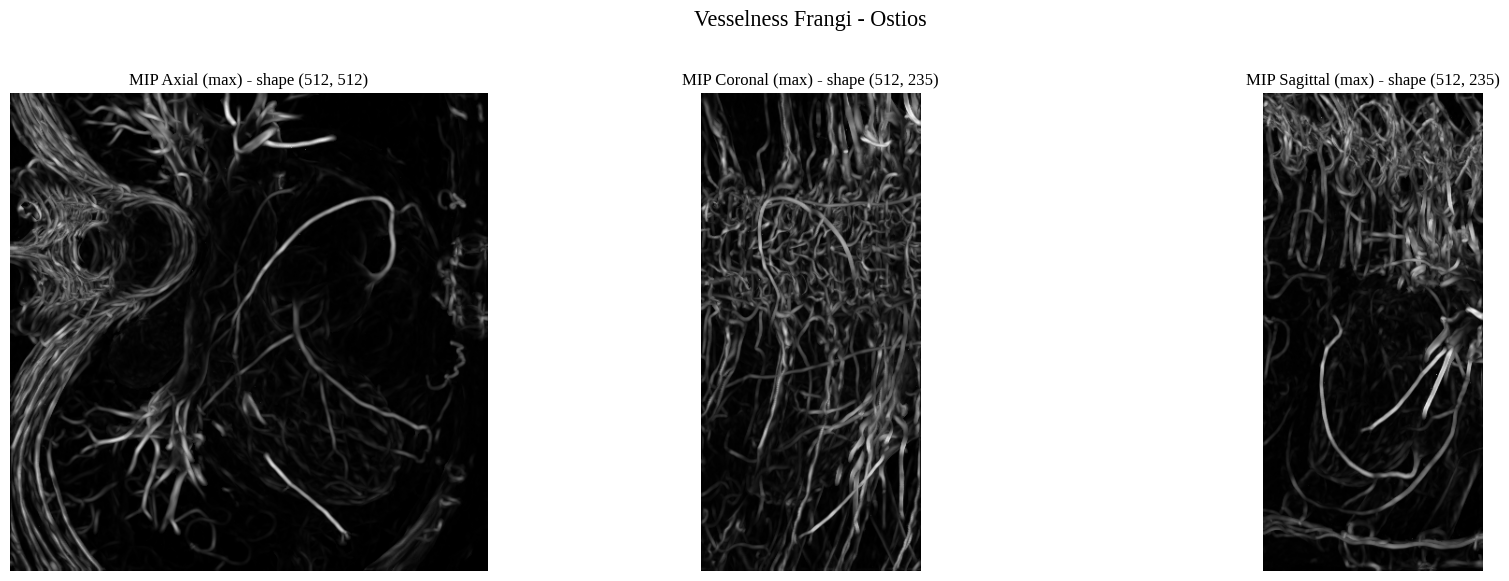

In [7]:
vesselness_cache_dir = f'{base_save_path}/vesselness_cache'
vesselness_ostia = get_or_compute_vesselness(
    IMG_ID,
    lcc_image,
    cache_dir=vesselness_cache_dir,
    vesselness_config=CONFIG['VESSELNESS_AORTA'],
    load_cache=LOAD_CACHE,
    save_cache=SAVE_CACHE,
)

if LOAD_CACHE and os.path.exists(os.path.join(vesselness_cache_dir, f'{IMG_ID}_vesselness.npy')):
    print('=' * 70)
    print('MAPA DE VESSELNESS (OSTIOS) - CARREGADO DO CACHE')
    print('=' * 70)
else:
    print('=' * 70)
    print('MAPA DE VESSELNESS (OSTIOS) - CALCULADO')
    print('=' * 70)

print(f"Shape:   {vesselness_ostia.shape}")
print(f"Range:   [{vesselness_ostia.min():.4f}, {vesselness_ostia.max():.4f}]")
print(f"Media:   {vesselness_ostia.mean():.4f}")
print(f"Desvpad: {vesselness_ostia.std():.4f}")
print('=' * 70 + '\n')

plot_mip_projection(vesselness_ostia, title='Vesselness Frangi - Ostios', cmap='gray')

In [8]:
print('=' * 70)
print('VISUALIZACAO: VESSELNESS (OSTIOS) vs GROUND TRUTH')
print('=' * 70 + '\n')

truth_mask = np.logical_and(label, vesselness_ostia > 0)

print(f"Voxels intersectados: {np.sum(truth_mask):,}\n")

plot = visualize_3d_k3d(
    truth_mask,
    spacing=(dx, dy, dz),
    color=0xff0000,
    opacity=0.7,
)

print('Visualizacao 3D criada\n')
print('=' * 70 + '\n')

VISUALIZACAO: VESSELNESS (OSTIOS) vs GROUND TRUTH

Voxels intersectados: 64,259

Gerando mesh 3D...


Output()

Visualizacao 3D criada




## Calcular mapa de vasos para artérias

MAPA DE VESSELNESS (ARTERIAS) - CALCULADO
Shape:   (512, 512, 235)
Range:   [0.0000, 0.7912]
Media:   0.0021
Desvpad: 0.0147



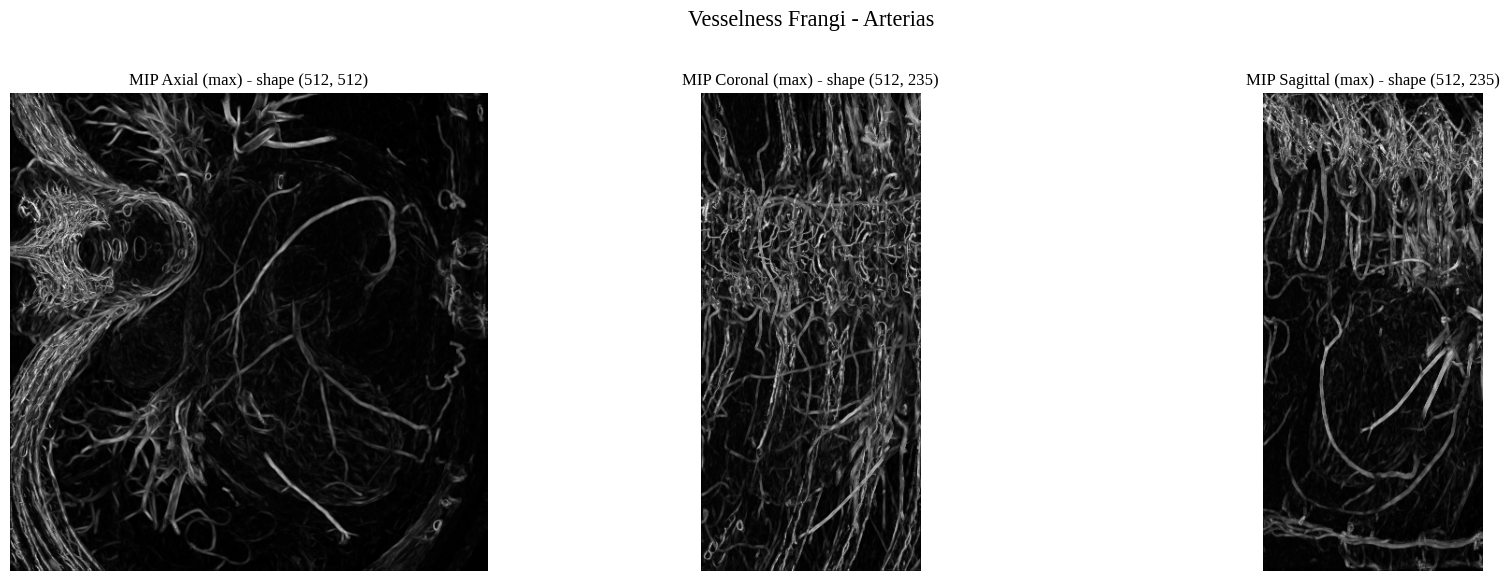

In [9]:
vesselness_cache_dir_artery = f'{base_save_path}/vesselness_cache_artery'
vesselness_artery = get_or_compute_vesselness(
    IMG_ID,
    lcc_image,
    cache_dir=vesselness_cache_dir_artery,
    vesselness_config=CONFIG['VESSELNESS_ARTERY'],
    load_cache=LOAD_CACHE,
    save_cache=SAVE_CACHE,
)

if LOAD_CACHE and os.path.exists(os.path.join(vesselness_cache_dir_artery, f'{IMG_ID}_vesselness.npy')):
    print('=' * 70)
    print('MAPA DE VESSELNESS (ARTERIAS) - CARREGADO DO CACHE')
    print('=' * 70)
else:
    print('=' * 70)
    print('MAPA DE VESSELNESS (ARTERIAS) - CALCULADO')
    print('=' * 70)

print(f"Shape:   {vesselness_artery.shape}")
print(f"Range:   [{vesselness_artery.min():.4f}, {vesselness_artery.max():.4f}]")
print(f"Media:   {vesselness_artery.mean():.4f}")
print(f"Desvpad: {vesselness_artery.std():.4f}")
print('=' * 70 + '\n')

plot_mip_projection(vesselness_artery, title='Vesselness Frangi - Arterias', cmap='gray')

In [10]:
print('=' * 70)
print('VISUALIZACAO: VESSELNESS (OSTIOS) vs GROUND TRUTH')
print('=' * 70 + '\n')

truth_mask = np.logical_and(label, vesselness_artery > 0)

print(f"Voxels intersectados: {np.sum(truth_mask):,}\n")

plot = visualize_3d_k3d(
    truth_mask,
    spacing=(dx, dy, dz),
    color=0xff0000,
    opacity=0.7,
)

print('Visualizacao 3D criada\n')
print('=' * 70 + '\n')

VISUALIZACAO: VESSELNESS (OSTIOS) vs GROUND TRUTH

Voxels intersectados: 58,367

Gerando mesh 3D...


Output()

Visualizacao 3D criada




## Encontrar os óstios

In [11]:
print('=' * 70)
print('DETECCAO DOS OSTIOS CORONARIOS')
print('=' * 70 + '\n')

ostia_left, ostia_right = find_ostia(
    aorta_mask,
    vesselness_ostia,
    spacing=(dy, dx, dz),
    top_n=CONFIG['OSTIA_DETECTION']['top_n'],
    max_z_diff_mm=CONFIG['OSTIA_DETECTION']['max_z_diff_mm'],
    lower_fraction=CONFIG['OSTIA_DETECTION']['lower_fraction'],
    min_center_distance_factor=CONFIG['OSTIA_DETECTION']['min_center_distance_factor'],
    min_lateral_factor=CONFIG['OSTIA_DETECTION']['min_lateral_factor'],
    erosion_radius=CONFIG['OSTIA_DETECTION']['erosion_radius'],
)

y_l, x_l, z_l = ostia_left
y_r, x_r, z_r = ostia_right

print('Coordenadas Detectadas (em voxels):')
print(f"  Ostio Esquerdo:  (x: {x_l:4.0f}, y: {y_l:4.0f}, z: {z_l:4.0f})")
print(f"  Ostio Direito:   (x: {x_r:4.0f}, y: {y_r:4.0f}, z: {z_r:4.0f})")
print('=' * 70 + '\n')

DETECCAO DOS OSTIOS CORONARIOS

Coordenadas Detectadas (em voxels):
  Ostio Esquerdo:  (x:  394, y:  196, z:  165)
  Ostio Direito:   (x:  281, y:  221, z:  169)



In [12]:
print('=' * 70)
print('VALIDACAO DOS OSTIOS DETECTADOS')
print('=' * 70 + '\n')

label_artery = (label == 1).astype(np.uint8)
tol_mm = CONFIG['OSTIA_VALIDATION']['distance_threshold_mm']

left_info = check_ostium_intersection(
    ostia_left,
    label_artery,
    spacing=(dy, dx, dz),
    ostium_name='Ostio Esquerdo',
    distance_threshold_mm=CONFIG['OSTIA_VALIDATION']['distance_threshold_mm'],
)

right_info = check_ostium_intersection(
    ostia_right,
    label_artery,
    spacing=(dy, dx, dz),
    ostium_name='Ostio Direito',
    distance_threshold_mm=CONFIG['OSTIA_VALIDATION']['distance_threshold_mm'],
)

print('Ostio Esquerdo:')
if left_info['intersects']:
    print(' Intersecta o label de ground truth')
else:
    print(' NAO intersecta o label')
    print(f" Distancia euclidiana: {left_info['euclidean_dist']:.2f} voxels")
    print(f" Distancia fisica: {left_info['physical_dist']:.2f} mm")
left_toleravel = left_info['intersects'] or left_info['physical_dist'] <= tol_mm
print(f" Toleravel ({tol_mm:.1f} mm): {'SIM' if left_toleravel else 'NAO'}")

print('\nOstio Direito:')
if right_info['intersects']:
    print(' Intersecta o label de ground truth')
else:
    print(' NAO intersecta o label')
    print(f" Distancia euclidiana: {right_info['euclidean_dist']:.2f} voxels")
    print(f" Distancia fisica: {right_info['physical_dist']:.2f} mm")
right_toleravel = right_info['intersects'] or right_info['physical_dist'] <= tol_mm
print(f" Toleravel ({tol_mm:.1f} mm): {'SIM' if right_toleravel else 'NAO'}")

print('\n' + '=' * 70)
if left_info['intersects'] and right_info['intersects']:
    print('RESULTADO: Ambos os ostios estao CORRETOS')
elif left_toleravel and right_toleravel:
    print('RESULTADO: Ambos os ostios estao dentro da tolerancia')
else:
    total_dist_voxels = left_info['euclidean_dist'] + right_info['euclidean_dist']
    total_dist_mm = left_info['physical_dist'] + right_info['physical_dist']
    print('RESULTADO: Ostios fora do esperado')
    print(f" Distancia total: {total_dist_voxels:.2f} voxels ({total_dist_mm:.2f} mm)")
    print('=' * 70 + '\n')

VALIDACAO DOS OSTIOS DETECTADOS

Ostio Esquerdo:
 Intersecta o label de ground truth
 Toleravel (8.0 mm): SIM

Ostio Direito:
 NAO intersecta o label
 Distancia euclidiana: 58.74 voxels
 Distancia fisica: 22.40 mm
 Toleravel (8.0 mm): NAO

RESULTADO: Ostios fora do esperado
 Distancia total: 58.74 voxels (22.40 mm)



In [13]:
print('=' * 70)
print('VISUALIZACAO: AORTA COM OSTIOS')
print('=' * 70 + '\n')

plot = visualize_aorta_with_ostia(
    aorta_mask,
    ostia_left,
    ostia_right,
    spacing=(dy, dx, dz),
    label_mask=label_artery,
    use_physical_coords=True,
)

print('Visualizacao 3D criada (K3D)\n')

if SAVE_CACHE:
    html_output_dir = '../output/segmented_ostios'
    html_path = os.path.join(html_output_dir, f'{IMG_ID}_aorta_ostia.html')
    os.makedirs(html_output_dir, exist_ok=True)

    with open(html_path, 'w') as f:
        f.write(plot.get_snapshot())

    print(f"Plot HTML salvo em: {html_path}\n")
else:
    print('=' * 70 + '\n')
    print('Plot nao foi salvo (SAVE_CACHE=False)\n')

VISUALIZACAO: AORTA COM OSTIOS



Output()

Visualizacao 3D criada (K3D)


Plot nao foi salvo (SAVE_CACHE=False)



## Segmentar artéria via crescimento de região

In [14]:
if 'threshold_divisor' not in CONFIG['REGION_GROWING'] and 'threshold_factor' in CONFIG['REGION_GROWING']:
    CONFIG['REGION_GROWING']['threshold_divisor'] = CONFIG['REGION_GROWING']['threshold_factor']
if 'min_vesselness_fraction' not in CONFIG['REGION_GROWING'] and 'min_vesselness_factor' in CONFIG['REGION_GROWING']:
    CONFIG['REGION_GROWING']['min_vesselness_fraction'] = CONFIG['REGION_GROWING']['min_vesselness_factor']
if 'verbose' not in CONFIG['REGION_GROWING']:
    CONFIG['REGION_GROWING']['verbose'] = False

print('=' * 70)
print('SEGMENTACAO DE ARTERIAS - CRESCIMENTO DE REGIAO')
print('=' * 70 + '\n')

threshold = (vesselness_artery.max() - vesselness_artery.min()) / CONFIG['REGION_GROWING']['threshold_divisor']
min_vesselness = vesselness_artery.max() * CONFIG['REGION_GROWING']['min_vesselness_fraction']

region_growing_params = {
    'threshold': threshold,
    'max_volume': CONFIG['REGION_GROWING']['max_volume'],
    'min_vesselness': min_vesselness,
    'relaxed_floor_factor': CONFIG['REGION_GROWING']['relaxed_floor_factor'],
    'switch_at_voxels': CONFIG['REGION_GROWING']['switch_at_voxels'],
    'comparison_window': CONFIG['REGION_GROWING']['comparison_window'],
    'smooth_relaxation': CONFIG['REGION_GROWING']['smooth_relaxation'],
    'verbose': CONFIG['REGION_GROWING']['verbose'],
}

print('Parametros calculados:')
print(f"  Threshold:       {threshold:.4f}")
print(f"  Min vesselness:  {min_vesselness:.4f}")
print(f"  Max volume:      {CONFIG['REGION_GROWING']['max_volume']:,} voxels\n")

print('1. Segmentando arteria esquerda...')
left_mask = region_growing_segmentation(
    vesselness_artery,
    seed_point=ostia_left,
    **region_growing_params,
)
print(f"   Voxels segmentados: {np.sum(left_mask):,}")

print('\n2. Segmentando arteria direita...')
right_mask = region_growing_segmentation(
    vesselness_artery,
    seed_point=ostia_right,
    **region_growing_params,
)
print(f"   Voxels segmentados: {np.sum(right_mask):,}")

mesh_artery_mask = left_mask + right_mask
print('\n3. Combinando segmentacoes...')
print(f"   Total de voxels: {np.sum(mesh_artery_mask):,}\n")

print('4. Pos-processamento morfologico...')
closed_mask = binary_closing(
    mesh_artery_mask > 0,
    structure=ball(CONFIG['POSTPROCESSING']['closing_radius']),
).astype(np.uint8)
print(
    f"   Apos fechamento (closing):  {np.sum(closed_mask):,} voxels "
    f"(+{np.sum(closed_mask) - np.sum(mesh_artery_mask):,})"
 )

dilated_mask = binary_dilation(
    closed_mask,
    structure=ball(CONFIG['POSTPROCESSING']['dilation_radius']),
).astype(np.uint8)
print(
    f"   Apos dilatacao:             {np.sum(dilated_mask):,} voxels "
    f"(+{np.sum(dilated_mask) - np.sum(mesh_artery_mask):,})\n"
 )

mesh_artery_mask = dilated_mask

print('=' * 70)
print('RESUMO DA SEGMENTACAO DE ARTERIAS')
print('=' * 70)
print(f"Segmentacao original:     {np.sum(left_mask + right_mask):>8,} voxels")
print(f"Apos pos-processamento:   {np.sum(mesh_artery_mask):>8,} voxels")
print('=' * 70 + '\n')

plot = visualize_aorta_with_ostia(
    mesh_artery_mask,
    ostia_left,
    ostia_right,
    spacing=(dy, dx, dz),
    label_mask=label_artery,
    use_physical_coords=True,
)

print('Visualizacao 3D criada\n')

SEGMENTACAO DE ARTERIAS - CRESCIMENTO DE REGIAO

Parametros calculados:
  Threshold:       0.0659
  Min vesselness:  0.0396
  Max volume:      400,000 voxels

1. Segmentando arteria esquerda...
   Voxels segmentados: 11,015

2. Segmentando arteria direita...
   Voxels segmentados: 576

3. Combinando segmentacoes...
   Total de voxels: 11,591

4. Pos-processamento morfologico...
   Apos fechamento (closing):  12,483 voxels (+892)
   Apos dilatacao:             79,050 voxels (+67,459)

RESUMO DA SEGMENTACAO DE ARTERIAS
Segmentacao original:       11,591 voxels
Apos pos-processamento:     79,050 voxels



Output()

Visualizacao 3D criada



## Avaliar Segmentação - Dice Score

In [15]:
print('=' * 70)
print('AVALIACAO DA SEGMENTACAO')
print('=' * 70 + '\n')

label_coronary = (label == 1).astype(np.uint8)
dice_total = dice_score(mesh_artery_mask, label_coronary)

true_positives = np.sum((mesh_artery_mask > 0) & label_coronary)
predicted_voxels = np.sum(mesh_artery_mask)
ground_truth_voxels = np.sum(label_coronary)

print('Metricas de Segmentacao:')
print(f"  Dice Score:              {dice_total:.4f}")
print(f"  Voxels Preditos:         {predicted_voxels:>8,}")
print(f"  Voxels Ground Truth:     {ground_truth_voxels:>8,}")
print(f"  Intersecao (TP):         {true_positives:>8,}")

if ground_truth_voxels > 0:
    sensitivity = true_positives / ground_truth_voxels
    print(f"  Sensibilidade:           {sensitivity:>8.4f}")

if predicted_voxels > 0:
    ppv = true_positives / predicted_voxels
    print(f"  Valor Preditivo Positivo:{ppv:>8.4f}")

print('=' * 70 + '\n')

AVALIACAO DA SEGMENTACAO

Metricas de Segmentacao:
  Dice Score:              0.4739
  Voxels Preditos:           79,050
  Voxels Ground Truth:      105,626
  Intersecao (TP):           43,762
  Sensibilidade:             0.4143
  Valor Preditivo Positivo:  0.5536

